In [1]:
# impoting libraries 
import pandas as pd
import matplotlib.pyplot as plt 
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


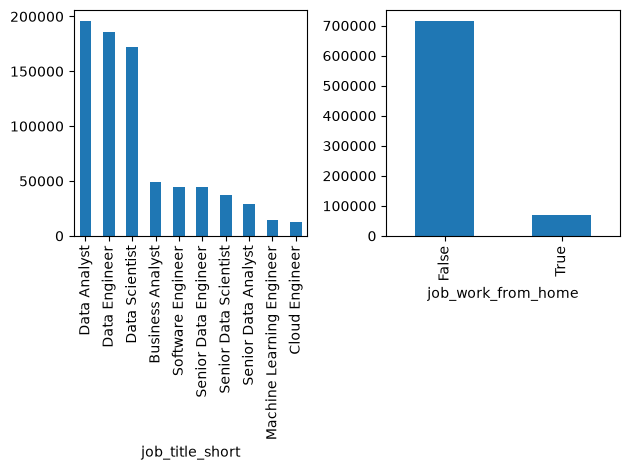

In [2]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_work_from_home'].value_counts().plot(kind="bar",ax = ax[1])

fig.tight_layout()

In [13]:
df_ex = df.explode('job_skills')
df_skills_count = df_ex.groupby(['job_title_short','job_skills']).size()


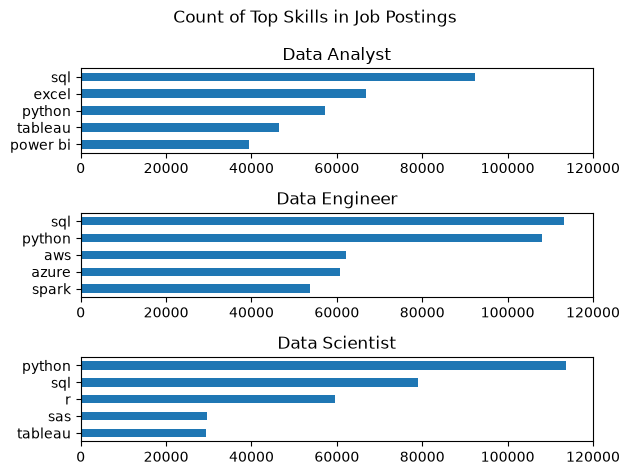

In [58]:
# df_skills_count = df_skills_count.reset_index(name = 'skill_count')
# df_skills_count.sort_values('skill_count',ascending=False,inplace=True)

fig, ax = plt.subplots(3,1)

job_titles = ["Data Analyst","Data Engineer","Data Scientist"]

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh',x = 'job_skills', y='skill_count', ax=ax[i], title = job_title)
    ax[i].invert_yaxis()
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000)
    ax[i].set_ylabel('')

fig.suptitle("Count of Top Skills in Job Postings")
fig.tight_layout()

